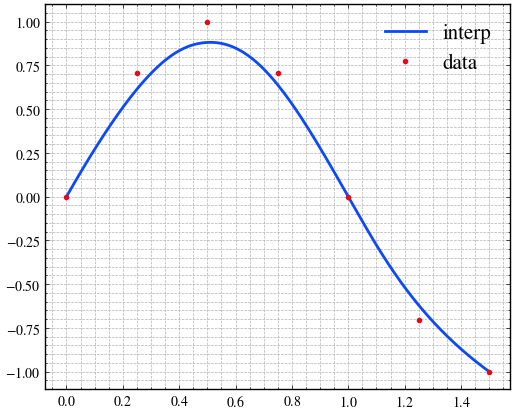

In [3]:
from scipy.interpolate import make_interp_spline ,BSpline
import numpy as np 
import matplotlib.pyplot as plt 
import scienceplots
import casadi as ca 

x = np.linspace(0, 3/2, 7)
y = np.sin(np.pi*x)

def bspline_curve_2d(control_points, degree=3, num_points=200):
    """
    参数
    ----
    control_points : array-like, shape (n, 2)
        二维控制点，如 [[0,0], [1,2], [3,1], [4,0]]
    degree : int
        B-spline 次数
    num_points : int
        输出曲线采样点数量

    返回
    ----
    curve : ndarray, shape (num_points, 2)
        曲线上的采样点
    """
    ctrl = np.asarray(control_points, dtype=float)

    if ctrl.ndim != 2 or ctrl.shape[1] != 2:
        raise ValueError("control_points 必须是 shape=(n,2) 的二维点数组")

    n = len(ctrl)
    if n < 2:
        raise ValueError("至少需要 2 个控制点")

    # 次数不能大于 n-1
    k = min(degree, n - 1)

    # 构造 open uniform knot vector
    # 节点向量长度 = n + k + 1
    t = np.concatenate((
        np.zeros(k),
        np.linspace(0, 1, n - k + 1),
        np.ones(k)
    ))

    # 直接把二维控制点作为系数传给 BSpline
    spline = BSpline(t, ctrl, k)

    # 参数范围 [0, 1]
    u = np.linspace(0, 1, num_points)
    curve = spline(u)

    return curve

xxyy=bspline_curve_2d(np.vstack([x,y]).T)

with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(111)
        ax.plot(xxyy[:,0], xxyy[:,1], label="interp")
        ax.plot(x,y,"o",label="data")
        ax.legend(fontsize=15)
        plt.show()

In [ ]:
import casadi as ca
import numpy as np


def open_uniform_knots(n_ctrl: int, degree: int):
    p = degree
    if n_ctrl < p + 1:
        raise ValueError(f"需要 n_ctrl >= degree+1, 当前 n_ctrl={n_ctrl}, degree={p}")

    n_internal = n_ctrl - p - 1
    if n_internal > 0:
        internal = np.linspace(0.0, 1.0, n_internal + 2)[1:-1]
        knots = np.r_[np.zeros(p + 1), internal, np.ones(p + 1)]
    else:
        knots = np.r_[np.zeros(p + 1), np.ones(p + 1)]
    return knots


def bspline_basis_casadi(i, p, knots, t):
    # 0次基函数
    if p == 0:
        # 处理最后一个节点，使 t=1 时最后一个基函数取1
        if i == len(knots) - 2:
            return ca.if_else((t >= knots[i]) * (t <= knots[i + 1]), 1.0, 0.0)
        else:
            return ca.if_else((t >= knots[i]) * (t < knots[i + 1]), 1.0, 0.0)

    denom1 = knots[i + p] - knots[i]
    denom2 = knots[i + p + 1] - knots[i + 1]

    term1 = 0
    term2 = 0

    if abs(denom1) > 1e-12:
        term1 = (t - knots[i]) / denom1 * bspline_basis_casadi(i, p - 1, knots, t)

    if abs(denom2) > 1e-12:
        term2 = (knots[i + p + 1] - t) / denom2 * bspline_basis_casadi(i + 1, p - 1, knots, t)

    return term1 + term2

    

def bspline_curve_casadi(control_points, degree=3):
    P = np.asarray(control_points, dtype=float)
    if P.ndim != 2:
        raise ValueError("control_points 必须是二维数组 (n_ctrl, dim)")

    n_ctrl, dim = P.shape
    knots = open_uniform_knots(n_ctrl, degree)

    t = ca.SX.sym("t")
    C = ca.SX.zeros(dim)

    for i in range(n_ctrl):
        Ni = bspline_basis_casadi(i, degree, knots, t)
        for d in range(dim):
            C[d] += Ni * P[i, d]

    spline_func = ca.Function("bspline_curve", [t], [C])
    return spline_func, knots

ctrl = np.array([
    [0.0, 0.0],
    [1.0, 2.0],
    [3.0, 3.0],
    [4.0, 0.0],
    [5.0, 2.0]
])

spline, knots = bspline_curve_casadi(ctrl, degree=3)

print("knots =", knots)

# 计算 t=0.3 处的曲线点
pt = spline(np.linspace(0,1,100))
print("C(0.3) =", pt)


with plt.style.context(["science", "nature", "high-vis", "no-latex"]):
    with plt.rc_context(
        {
            "axes.linewidth": 1,
            "lines.linewidth": 2,
            "axes.labelsize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.grid": True,
            "axes.grid.which": "both",
            "grid.linestyle": "--",
            # "figure.subplot.wspace":0.5
        }
    ):
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(111)
        ax.plot(pt[:, 0], pt[:, 1], color="magenta", label="interp")
        ax.plot(ctrl[:, 0], ctrl[:, 1], "--go", label="cts", markersize=6, markerfacecolor="b", markeredgecolor="b")
        ax.legend(fontsize=15)
        plt.show()

knots = [0.  0.  0.  0.  0.5 1.  1.  1.  1. ]


RuntimeError: Error in Function::call for 'bspline_curve' [SXFunction] at .../casadi/core/function.cpp:362:
.../casadi/core/function_internal.hpp:1728: Input 0 (i0) has mismatching shape. Got 100-by-1. Allowed dimensions, in general, are:
 - The input dimension N-by-M (here 1-by-1)
 - A scalar, i.e. 1-by-1
 - M-by-N if N=1 or M=1 (i.e. a transposed vector)
 - N-by-M1 if K*M1=M for some K (argument repeated horizontally)
 - N-by-P*M, indicating evaluation with multiple arguments (P must be a multiple of 1 for consistency with previous inputs)